# 05. Model comparison

**Goal.** Score every model on identical test origins (two per day,
00:00 and 12:00 AEST, eight weeks) with identical features and weather
variants, and answer three questions: who forecasts best, whose
uncertainty is honest and what each result costs to compute.

The field:

- **Seasonal naive**: same half hour last week with a Gaussian band; the
  floor and the MASE base.
- **ARIMA**: dynamic harmonic regression with ARIMA errors, the
  classical baseline, analytic Gaussian predictive.
- **LightGBM**: fifteen pinball-objective quantile heads on the shared
  design plus the origin-anchored recency features.
- **BART**: two sum-of-trees heads (mean and log scale) on the same
  design as LightGBM, fitted by particle Gibbs; full predictive draws.
- **Bayesian AR(1)**: the repaired model of notebooks 03 and 04, fitted
  by mean-field ADVI, full-rank ADVI and warm-started NUTS (the
  reference posterior), plus a homoskedastic ablation that prices the
  variance head.

Scores: CRPS (primary), log score, pinball, MAE, MASE, central coverage,
PIT and the energy score over whole 48-step paths. Representation
differences are respected: the energy score needs coherent sampled
paths, so it exists only for the Bayesian models; LightGBM's CRPS uses
the quantile-integral estimator, its point forecast is the median head
and it has no log score (no density).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from nemforecastdemand.config import load_config
from nemforecastdemand.data.loaders import load_splits
from nemforecastdemand.evaluation.calibration import pit_gaussian, pit_histogram, pit_samples
from nemforecastdemand.evaluation.diagnostics import time_to_target_ess
from nemforecastdemand.evaluation.metrics import (
    crps_gaussian,
    crps_samples,
    energy_score,
    interval_coverage,
    log_score_gaussian,
    log_score_samples,
    mase,
    paired_bootstrap_difference,
    pinball_loss,
)
from nemforecastdemand.plotting import fan_chart, horizon_curve, palette, save_figure, setup_style
from nemforecastdemand.splits import rolling_origins
from nemforecastdemand.utils import load_artifact

setup_style()
cfg = load_config()
splits = load_splits(cfg.paths.processed)
panel = pd.concat([splits["train"], splits["validation"], splits["test"]])

arima, arima_meta = load_artifact(cfg.paths.artifacts / "arima")
gbdt, gbdt_meta = load_artifact(cfg.paths.artifacts / "gbdt")
bart, bart_meta = load_artifact(cfg.paths.artifacts / "bart")
ar_nuts, ar_nuts_meta = load_artifact(
    cfg.paths.artifacts / "bsts_innovations_nuts_warm_fullrank_w300"
)
ar_homo, ar_homo_meta = load_artifact(cfg.paths.artifacts / "bsts_innovations_nuts_homoskedastic")
ar_vi = {
    k: load_artifact(cfg.paths.artifacts / f"bsts_innovations_vi_{k}")
    for k in ("meanfield", "fullrank")
}
test_origins = rolling_origins(
    splits["test"].index, panel.index, cfg.origins, cfg.horizon, max(cfg.features.demand_lags)
)
y_test = ar_nuts["y_test"]
quantile_levels = np.array(cfg.evaluation.quantiles)
gbdt_levels = np.array(gbdt_meta["quantile_levels"])

MODELS = [
    "seasonal naive",
    "ARIMA",
    "LightGBM",
    "BART",
    "Bayesian AR(1) homoskedastic",
    "Bayesian AR(1) MF-ADVI",
    "Bayesian AR(1) FR-ADVI",
    "Bayesian AR(1) NUTS",
]
COLOURS = {
    "seasonal naive": "#9a9a9a",
    "ARIMA": palette("forecast"),
    "LightGBM": "#2e7d32",
    "BART": "#7a4988",
    "Bayesian AR(1) homoskedastic": "#b0884d",
    "Bayesian AR(1) MF-ADVI": palette("demand"),
    "Bayesian AR(1) FR-ADVI": palette("accent"),
    "Bayesian AR(1) NUTS": "black",
}
PIT_MODELS = ["ARIMA", "LightGBM", "BART", "Bayesian AR(1) NUTS"]


def gaussian_scores(mean: np.ndarray, sd: np.ndarray) -> dict:
    crps = crps_gaussian(y_test, mean, sd)
    quantile_paths = mean[None] + stats.norm.ppf(quantile_levels)[:, None, None] * sd[None]
    cover = {
        level: interval_coverage(
            y_test.ravel(),
            (mean - stats.norm.ppf(0.5 + level / 2) * sd).ravel(),
            (mean + stats.norm.ppf(0.5 + level / 2) * sd).ravel(),
        )
        for level in cfg.evaluation.interval_levels
    }
    return {
        "per_origin_crps": crps.mean(axis=1),
        "per_step_crps": crps,
        "point": mean,
        "log_score": log_score_gaussian(y_test, mean, sd).mean(),
        "pinball": pinball_loss(
            y_test.ravel(), quantile_paths.reshape(len(quantile_levels), -1), quantile_levels
        ).mean(),
        "coverage": cover,
        "energy": np.nan,
        "pit": pit_gaussian(y_test.ravel(), mean.ravel(), sd.ravel()),
    }


def sample_scores(paths: np.ndarray) -> dict:
    n_origins = y_test.shape[0]
    crps = np.stack(
        [
            crps_samples(y_test[i], paths[:, i, :], chunk=cfg.evaluation.crps_chunk)
            for i in range(n_origins)
        ]
    )
    quantile_paths = np.quantile(paths, quantile_levels, axis=0)
    mean = paths.mean(axis=0)
    cover = {}
    for level in cfg.evaluation.interval_levels:
        lower = np.quantile(paths, 0.5 - level / 2, axis=0)
        upper = np.quantile(paths, 0.5 + level / 2, axis=0)
        cover[level] = interval_coverage(y_test.ravel(), lower.ravel(), upper.ravel())
    return {
        "per_origin_crps": crps.mean(axis=1),
        "per_step_crps": crps,
        "point": mean,
        "log_score": np.mean(
            [log_score_samples(y_test[i], paths[:, i, :]).mean() for i in range(n_origins)]
        ),
        "pinball": pinball_loss(
            y_test.ravel(),
            quantile_paths.reshape(len(quantile_levels), -1),
            quantile_levels,
        ).mean(),
        "coverage": cover,
        "energy": np.mean(
            [
                energy_score(y_test[i], paths[:, i, :], chunk=cfg.evaluation.crps_chunk)
                for i in range(n_origins)
            ]
        ),
        "pit": np.concatenate([pit_samples(y_test[i], paths[:, i, :]) for i in range(n_origins)]),
    }


def quantile_scores(quantile_paths: np.ndarray) -> dict:
    """Scores for the quantile-head forecaster, shape ``(O, Q, H)``."""
    from nemforecastdemand.evaluation.metrics import crps_from_quantiles

    n_origins = y_test.shape[0]
    crps = np.stack(
        [crps_from_quantiles(y_test[i], quantile_paths[i], gbdt_levels) for i in range(n_origins)]
    )
    median = quantile_paths[:, gbdt_levels.tolist().index(0.5), :]
    report_idx = [gbdt_levels.tolist().index(q) for q in quantile_levels]
    cover = {}
    for level in cfg.evaluation.interval_levels:
        lower = quantile_paths[:, gbdt_levels.tolist().index(round(0.5 - level / 2, 3)), :]
        upper = quantile_paths[:, gbdt_levels.tolist().index(round(0.5 + level / 2, 3)), :]
        cover[level] = interval_coverage(y_test.ravel(), lower.ravel(), upper.ravel())
    # PIT by interpolating the discrete quantile function; observations
    # outside the trained 2.5/97.5 band clamp to 0 or 1, an approximation
    # visible only in the outer histogram bins.
    pit = np.array(
        [
            np.interp(y_test[i, j], quantile_paths[i, :, j], gbdt_levels, left=0.0, right=1.0)
            for i in range(n_origins)
            for j in range(y_test.shape[1])
        ]
    )
    return {
        "per_origin_crps": crps.mean(axis=1),
        "per_step_crps": crps,
        "point": median,
        "log_score": np.nan,
        "pinball": pinball_loss(
            y_test.ravel(),
            quantile_paths[:, report_idx, :].transpose(1, 0, 2).reshape(len(quantile_levels), -1),
            quantile_levels,
        ).mean(),
        "coverage": cover,
        "energy": np.nan,
        "pit": np.asarray(pit, dtype=np.float64),
    }


scores = {
    "seasonal naive": gaussian_scores(arima["naive_mean"], arima["naive_sd"]),
    "ARIMA": gaussian_scores(arima["forecast_mean"], arima["forecast_sd"]),
    "LightGBM": quantile_scores(gbdt["forecast_quantiles"]),
    "BART": sample_scores(bart["forecast_paths"]),
    "Bayesian AR(1) homoskedastic": sample_scores(ar_homo["forecast_paths"]),
    "Bayesian AR(1) MF-ADVI": sample_scores(ar_vi["meanfield"][0]["forecast_paths"]),
    "Bayesian AR(1) FR-ADVI": sample_scores(ar_vi["fullrank"][0]["forecast_paths"]),
    "Bayesian AR(1) NUTS": sample_scores(ar_nuts["forecast_paths"]),
}

## The master table

Archived day-ahead weather as issued, no look-ahead. MASE scales by the
seasonal-naive training MAE. The homoskedastic row is the ablation:
identical model and inference, constant innovation scale, so the gap to
the NUTS row is what the heteroskedastic head is worth.

In [2]:
table = {}
for name in MODELS:
    s = scores[name]
    row = {
        "CRPS (MW)": s["per_origin_crps"].mean(),
        "log score": s["log_score"],
        "pinball (MW)": s["pinball"],
        "MAE (MW)": np.abs(y_test - s["point"]).mean(),
        "MASE": mase(y_test.ravel(), s["point"].ravel(), arima_meta["naive_train_mae_mw"]),
        "energy score (MW)": s["energy"],
    }
    for level, value in s["coverage"].items():
        row[f"cover {level:.0%}"] = value
    table[name] = row
master = pd.DataFrame(table).T
master.round(2)

,CRPS (MW),log score,pinball (MW),MAE (MW),MASE,energy score (MW),cover 50%,cover 80%,cover 95%
seasonal naive,371.67,7.91,161.54,445.36,0.56,NaN,0.82,0.97,0.99
ARIMA,267.37,7.58,111.99,353.51,0.44,NaN,0.67,0.87,0.95
LightGBM,178.98,NaN,76.50,240.27,0.30,NaN,0.43,0.74,0.93
BART,222.61,7.32,93.92,291.34,0.37,2202.26,0.74,0.95,0.99
Bayesian AR(1) homoskedastic,279.37,7.64,117.11,370.07,0.46,2343.78,0.61,0.83,0.92
Bayesian AR(1) MF-ADVI,225.89,7.38,93.31,309.98,0.39,2028.87,0.44,0.74,0.89
Bayesian AR(1) FR-ADVI,226.17,7.38,93.41,310.68,0.39,2029.94,0.44,0.74,0.89
Bayesian AR(1) NUTS,226.15,7.38,93.41,310.61,0.39,2030.47,0.44,0.74,0.89


## Are the differences real?

Paired block bootstrap over origins on per-origin CRPS (10,000
resamples). Negative differences favour the first model.

In [3]:
pairs = [
    ("Bayesian AR(1) NUTS", "ARIMA"),
    ("Bayesian AR(1) NUTS", "LightGBM"),
    ("Bayesian AR(1) NUTS", "BART"),
    ("Bayesian AR(1) NUTS", "Bayesian AR(1) homoskedastic"),
    ("Bayesian AR(1) homoskedastic", "ARIMA"),
    ("LightGBM", "ARIMA"),
    ("BART", "LightGBM"),
    ("Bayesian AR(1) MF-ADVI", "Bayesian AR(1) NUTS"),
    ("ARIMA", "seasonal naive"),
]
sig_rows = {}
for a, b in pairs:
    result = paired_bootstrap_difference(
        scores[a]["per_origin_crps"], scores[b]["per_origin_crps"], seed=cfg.seed
    )
    sig_rows[f"{a} minus {b}"] = result
pd.DataFrame(sig_rows).T.round(3)

,difference,lower95,upper95,p_value
Bayesian AR(1) NUTS minus ARIMA,-41.220,-56.321,-26.666,0.000
Bayesian AR(1) NUTS minus LightGBM,47.164,32.754,61.805,0.000
Bayesian AR(1) NUTS minus BART,3.541,-9.907,17.587,0.630
Bayesian AR(1) NUTS minus Bayesian AR(1) homoskedastic,-53.222,-76.436,-32.210,0.000
Bayesian AR(1) homoskedastic minus ARIMA,12.001,3.927,20.968,0.001
LightGBM minus ARIMA,-88.385,-107.287,-71.329,0.000
BART minus LightGBM,43.623,35.393,51.774,0.000
Bayesian AR(1) MF-ADVI minus Bayesian AR(1) NUTS,-0.254,-0.597,0.066,0.129
ARIMA minus seasonal naive,-104.301,-124.969,-82.950,0.000


## Calibration

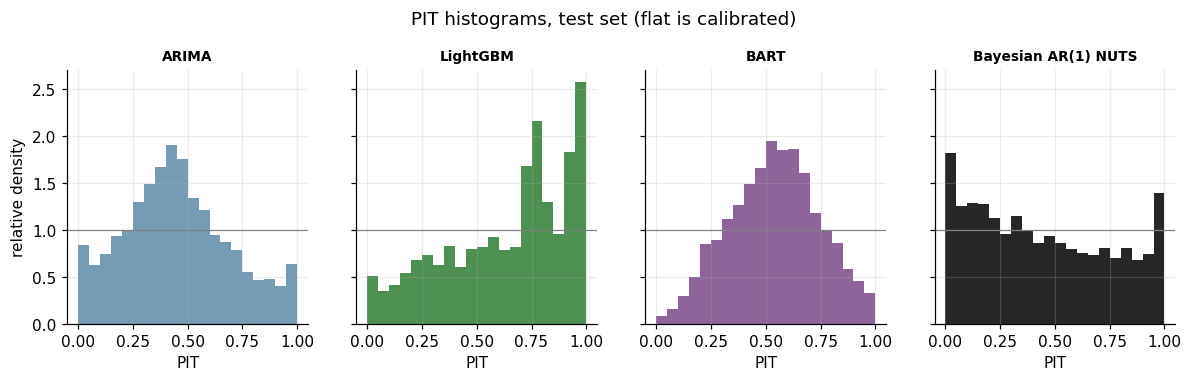

In [4]:
fig, axes = plt.subplots(1, len(PIT_MODELS), figsize=(13, 3), sharey=True)
for ax, name in zip(axes, PIT_MODELS, strict=True):
    density, edges = pit_histogram(scores[name]["pit"], bins=20)
    ax.bar(edges[:-1], density, width=np.diff(edges), align="edge", color=COLOURS[name], alpha=0.85)
    ax.axhline(1.0, color="grey", lw=0.8)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("PIT")
axes[0].set_ylabel("relative density")
fig.suptitle("PIT histograms, test set (flat is calibrated)", y=1.06)
save_figure(fig, "pit_comparison", cfg.paths.figures)
plt.show()

## Skill by lead time

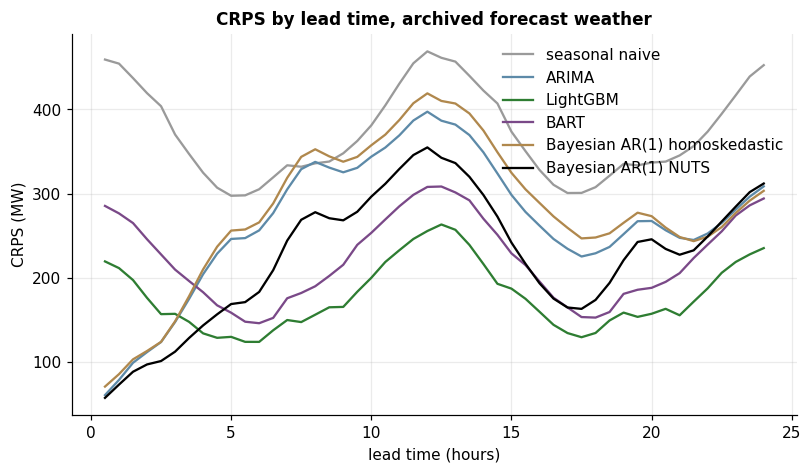

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
for name in MODELS:
    if name in ("Bayesian AR(1) MF-ADVI", "Bayesian AR(1) FR-ADVI"):
        continue  # nearly coincident with the NUTS posterior; the table carries them
    horizon_curve(ax, scores[name]["per_step_crps"], name, COLOURS[name])
ax.set_ylabel("CRPS (MW)")
ax.set_title("CRPS by lead time, archived forecast weather")
ax.legend()
save_figure(fig, "horizon_crps_all_models", cfg.paths.figures)
plt.show()

## Robustness to weather-input quality

The sweep degrades ERA5 actuals with the calibrated correlated error at
multiples of the measured day-ahead forecast error: 0 is perfect
foresight, 1 matches the real forecast's error magnitude, 2 doubles it.

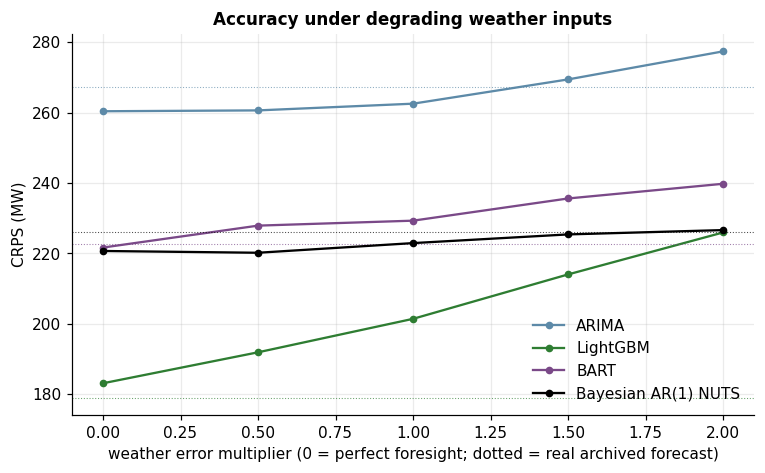

In [6]:
sweep_x = [0.0] + [m for m in cfg.perturbation.sweep_multipliers if m > 0]


def sweep_crps(name: str) -> list[float]:
    from nemforecastdemand.evaluation.metrics import crps_from_quantiles

    out = []
    for m in sweep_x:
        variant = "actual" if m == 0 else f"perturb_{m:g}"
        if name == "ARIMA":
            out.append(
                float(
                    crps_gaussian(y_test, arima[f"{variant}_mean"], arima[f"{variant}_sd"]).mean()
                )
            )
        elif name == "LightGBM":
            paths = gbdt[f"{variant}_quantiles"]
            out.append(
                float(
                    np.mean(
                        [
                            crps_from_quantiles(y_test[i], paths[i], gbdt_levels).mean()
                            for i in range(y_test.shape[0])
                        ]
                    )
                )
            )
        else:
            paths = {
                "BART": bart,
                "Bayesian AR(1) NUTS": ar_nuts,
            }[name][f"{variant}_paths"]
            out.append(
                float(
                    np.mean(
                        [
                            crps_samples(y_test[i], paths[:, i, :]).mean()
                            for i in range(y_test.shape[0])
                        ]
                    )
                )
            )
    return out


fig, ax = plt.subplots(figsize=(8, 4.5))
for name in ("ARIMA", "LightGBM", "BART", "Bayesian AR(1) NUTS"):
    values = sweep_crps(name)
    ax.plot(sweep_x, values, marker="o", ms=4, color=COLOURS[name], label=name)
    headline = scores[name]["per_origin_crps"].mean()
    ax.axhline(headline, color=COLOURS[name], lw=0.7, ls=":", alpha=0.7)
ax.set_xlabel("weather error multiplier (0 = perfect foresight; dotted = real archived forecast)")
ax.set_ylabel("CRPS (MW)")
ax.set_title("Accuracy under degrading weather inputs")
ax.legend()
save_figure(fig, "weather_sweep", cfg.paths.figures)
plt.show()

## Case study: the hardest day in the test set

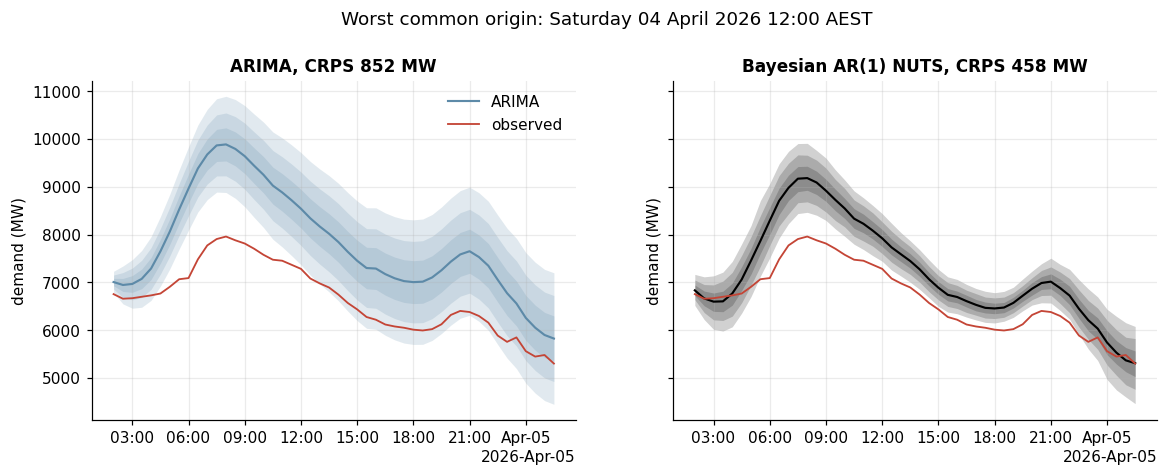

In [7]:
consensus = scores["Bayesian AR(1) NUTS"]["per_origin_crps"] + scores["ARIMA"]["per_origin_crps"]
worst = int(consensus.argmax())
origin = test_origins[worst]
index = pd.date_range(origin, periods=cfg.horizon, freq="30min")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4), sharey=True)
fan_chart(
    axes[0],
    index,
    mean=arima["forecast_mean"][worst],
    sd=arima["forecast_sd"][worst],
    colour=COLOURS["ARIMA"],
    label="ARIMA",
)
fan_chart(
    axes[1],
    index,
    samples=ar_nuts["forecast_paths"][:, worst, :],
    colour=COLOURS["Bayesian AR(1) NUTS"],
    label="Bayesian AR(1) NUTS",
)
for ax in axes:
    ax.plot(
        index.tz_convert("Australia/Brisbane"),
        y_test[worst],
        color="#c44536",
        lw=1.2,
        label="observed",
    )
    ax.set_ylabel("demand (MW)")
axes[0].set_title(f"ARIMA, CRPS {scores['ARIMA']['per_origin_crps'][worst]:.0f} MW")
axes[1].set_title(
    f"Bayesian AR(1) NUTS, CRPS {scores['Bayesian AR(1) NUTS']['per_origin_crps'][worst]:.0f} MW"
)
axes[0].legend()
fig.suptitle(
    f"Worst common origin: {origin.tz_convert('Australia/Brisbane'):%A %d %B %Y %H:%M} AEST", y=1.04
)
save_figure(fig, "worst_day_case_study", cfg.paths.figures)
plt.show()

## Compute

Wall-clock per model. The NUTS row charges the full pipeline it depends
on (full-rank ADVI fit plus reduced warmup plus sampling), because cold
NUTS does not produce a usable posterior for this model (notebook 04).
ESS-per-second uses the reference run's sampling time.

In [8]:
compute_rows = {
    "seasonal naive": {
        "fit (s)": 0.0,
        "forecast all origins (s)": arima_meta["timings_seconds"]["naive_forecasts"],
    },
    "ARIMA": {
        "fit (s)": arima_meta["timings_seconds"]["final_fit"],
        "forecast all origins (s)": arima_meta["timings_seconds"]["test_forecasts"],
    },
    "LightGBM": {
        "fit (s)": gbdt_meta["timings_seconds"]["fit"],
        "forecast all origins (s)": gbdt_meta["timings_seconds"]["test_forecasts"],
    },
    "BART": {
        "fit (s)": bart_meta["timings_seconds"]["fit_seconds"],
        "forecast all origins (s)": bart_meta["timings_seconds"]["predict_seconds"],
    },
    "Bayesian AR(1) MF-ADVI": {
        "fit (s)": ar_vi["meanfield"][1]["timings_seconds"]["fit_seconds"],
        "forecast all origins (s)": ar_vi["meanfield"][1]["timings_seconds"]["predict_seconds"],
    },
    "Bayesian AR(1) FR-ADVI": {
        "fit (s)": ar_vi["fullrank"][1]["timings_seconds"]["fit_seconds"],
        "forecast all origins (s)": ar_vi["fullrank"][1]["timings_seconds"]["predict_seconds"],
    },
    "Bayesian AR(1) NUTS": {
        "fit (s)": ar_nuts_meta["advi_seconds"]
        + ar_nuts_meta["timings_seconds"]["warmup_seconds"]
        + ar_nuts_meta["timings_seconds"]["sample_seconds"],
        "forecast all origins (s)": ar_nuts_meta["predict_seconds"],
        "min bulk ESS": ar_nuts_meta["min_bulk_ess"],
        "ESS per s": ar_nuts_meta["min_bulk_ess"]
        / ar_nuts_meta["timings_seconds"]["sample_seconds"],
        "to ESS 400 incl ADVI (s)": ar_nuts_meta["advi_seconds"]
        + time_to_target_ess(
            ar_nuts_meta["timings_seconds"]["warmup_seconds"],
            ar_nuts_meta["timings_seconds"]["sample_seconds"],
            ar_nuts_meta["min_bulk_ess"],
            cfg.warm_start.target_bulk_ess,
        ),
    },
}
compute = pd.DataFrame(compute_rows).T
compute.round(1)

,fit (s),forecast all origins (s),min bulk ESS,ESS per s,to ESS 400 incl ADVI (s)
seasonal naive,0.0,0.0,NaN,NaN,NaN
ARIMA,204.5,61.9,NaN,NaN,NaN
LightGBM,8.8,11.3,NaN,NaN,NaN
BART,893.8,152.5,NaN,NaN,NaN
Bayesian AR(1) MF-ADVI,3.1,3.8,NaN,NaN,NaN
Bayesian AR(1) FR-ADVI,3.8,3.2,NaN,NaN,NaN
Bayesian AR(1) NUTS,9.9,3.6,4618.4,3255.3,8.6


The warm-start grid from notebook 04, repeated for the headline: every
warm run meets quality, cold does not, and the whole Bayesian pipeline
now costs seconds.

In [9]:
warm_rows = {}
for kind in ("meanfield", "fullrank"):
    for reduced in cfg.warm_start.reduced_warmup:
        _, meta = load_artifact(
            cfg.paths.artifacts / f"bsts_innovations_nuts_warm_{kind}_w{reduced}"
        )
        timing = meta["timings_seconds"]
        warm_rows[f"warm {kind} w={reduced}"] = {
            "total incl ADVI (s)": meta["advi_seconds"]
            + time_to_target_ess(
                timing["warmup_seconds"],
                timing["sample_seconds"],
                meta["min_bulk_ess"],
                cfg.warm_start.target_bulk_ess,
            ),
            "max R-hat": meta["max_rhat"],
            "divergences": meta["total_divergences"],
        }
pd.DataFrame(warm_rows).T.round(2)

,total incl ADVI (s),max R-hat,divergences
warm meanfield w=100,11.17,1.01,0.0
warm meanfield w=300,9.24,1.01,0.0
warm fullrank w=100,8.23,1.00,0.0
warm fullrank w=300,8.63,1.00,0.0


## Conclusions

- Every model clears the naive floor. The Bayesian AR(1) beats the
  classical baseline by 41 MW CRPS (bootstrap CI roughly -57 to -27,
  p < 0.001) and the ablation attributes the gain to the
  heteroskedastic head: the same model with a constant scale gives 53
  of those megawatts back. BART and the Bayesian AR(1) are
  statistically tied (3.5 MW, p = 0.63).
- LightGBM wins marginal CRPS, and the gap is real (47 MW, p < 0.001).
  It is a point-accuracy gap, not an uncertainty gap: median MAE 240
  against 311, concentrated beyond five hours of lead time and in the
  evening ramp, where boosted trees flex the peak shape in ways a
  linear-in-features regression cannot. Within the first two hours the
  Bayesian AR(1) is the most accurate model in the field (first
  half-hour CRPS near 60 MW against LightGBM's 220), because the AR
  carry conditions on the latest observation and decays from there.
- What the quantile heads do not provide: a density (no log score),
  coherent 48-step paths (no energy score; the Bayesian AR(1) posts
  the best in the field) and any decomposition of predictive
  uncertainty. For decisions that span the horizon jointly, per-step
  quantiles are not a substitute for paths.
- Inference choice does not move prediction: mean-field, full-rank and
  NUTS forecast within a third of a megawatt of each other. The
  differences live in the posterior itself and in what it costs, which
  is notebook 04's accounting.